In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 48.7 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
directory_path = Path('/content/drive/MyDrive/data/data/RacingGame')
data_files = [str(file_path.resolve()) for file_path in directory_path.rglob('*.edf')]
print(data_files)
print(len(data_files))

['/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/260323_racingGame_winston_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/03__25_26_racingGame_andrew_01_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/270323_racingGame_Haoting_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/03_29_26_race_andy_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/04_05_26_racingGame_andy_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/04_07_26_racing_churek_raw.edf']
6


In [ ]:
import torch
import numpy as np
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
event_id = {
  "correct_left": 1,
  "correct_right": 2,
  "system_error_left": 3,
  "system_error_right": 4,

}

In [ ]:
import mne
import numpy as np

def load_raw_edf(edf_file_path):
  data = mne.io.read_raw_edf(edf_file_path, preload = True)
  print(data.info)
  print(f"Original channel names: {data.info.ch_names}")

  ### Reference to Left Ear channel, default is Pz ###
  data.set_eeg_reference(ref_channels=['EEG LE-Pz'])

  ### Standardize channel names ###
  rename_dict = {}
  for ch_name in data.ch_names:
      if '-Pz' in ch_name:
          rename_dict[ch_name] = ch_name.replace('-Pz', '')
      if ch_name == "Pz":
          rename_dict[ch_name] = "EEG Pz"
  data.rename_channels(rename_dict)
  print(f"Updated channel names: {data.info.ch_names}")

  ### Preprocess with bandpass ###
  data.filter(l_freq=1.0, h_freq=40.0, picks="eeg")

  ### Find events labeled in the Trigger column ###
  events = mne.find_events(data, stim_channel='Trigger', min_duration=0.0)
  print(f'Found {len(events)} events')
  print(f'Event IDs: {set(events[:, 2])}')
  print(f"Event Counts: {mne.count_events(events)}")
  ### Create epochs time locked to the event triggers ###
  epochs = mne.Epochs(
      data,
      events,
      event_id=event_id,
      tmin=-0.2,      # Start 200 ms before event
      tmax=0.8,       # End 800 ms after event
      baseline=(-0.2,0.0),  # Baseline period for correction
      preload=True,
      reject=None,
      reject_by_annotation=False,
  )
  channels = ['EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz']
  epochs = epochs.pick(channels)

  ### Plot epochs ###
  evokeds = [epochs[cond].average() for cond in list(event_id.keys())]
  mne.viz.plot_compare_evokeds(evokeds)

  ### Convert epochs and event labels to numpy ###
  samples = []
  labels = []
  for key in event_id.keys():
        datum = epochs[key].get_data()[:,:,:-1]
        samples.append(datum)
        labels.extend([key]*datum.shape[0])
  X = np.concatenate(samples, axis=0)
  y = np.array(labels)

  return X, y



Loading file #1/4
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/260323_racingGame_winston_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 174599  =      0.000 ...   581.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-23 18:32:36 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EE

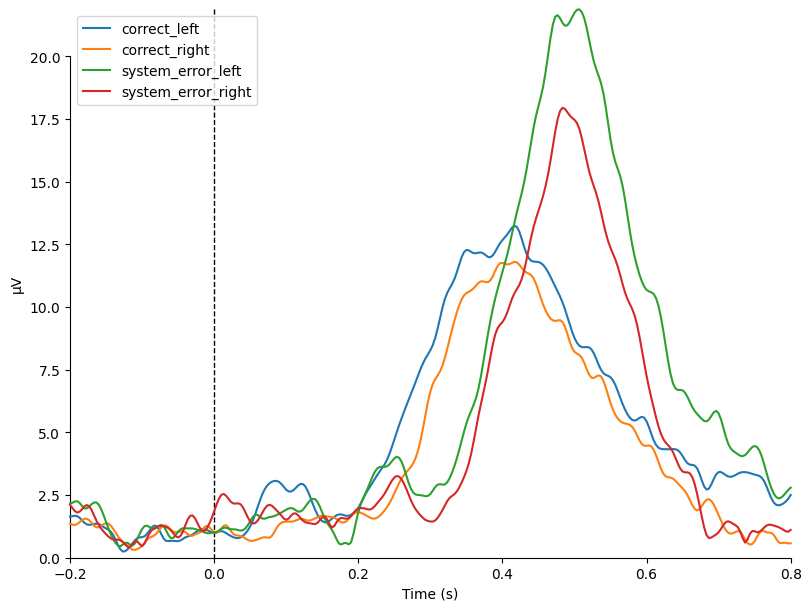

Loading file #2/4
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/03__25_26_racingGame_andrew_01_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 153599  =      0.000 ...   511.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-25 12:42:48 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3'

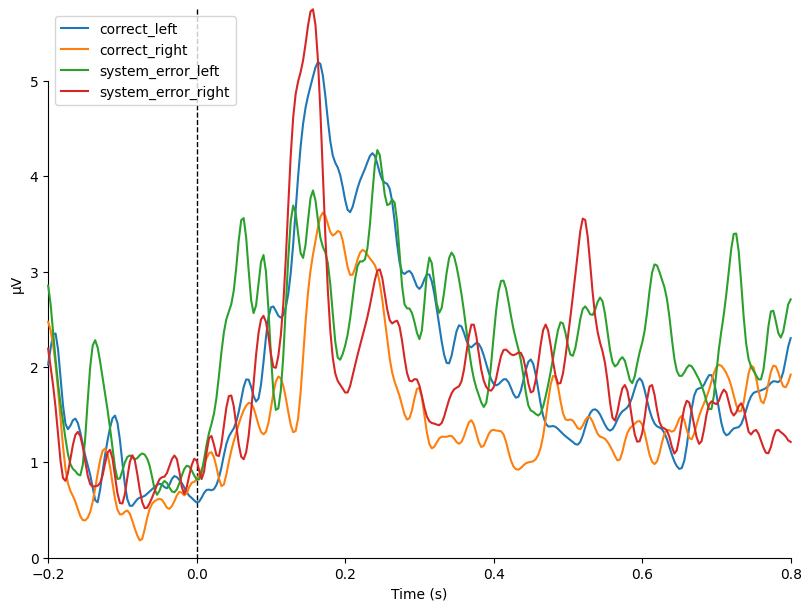

Loading file #3/4
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/270323_racingGame_Haoting_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 146399  =      0.000 ...   487.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-27 17:30:20 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EE

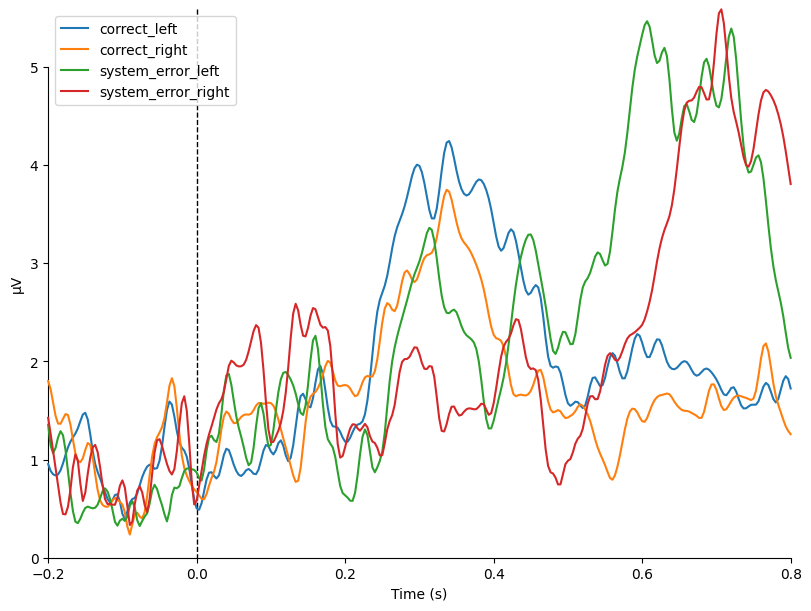

Loading file #4/4
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/04_07_26_racing_churek_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 196799  =      0.000 ...   655.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-04-07 17:23:05 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG P

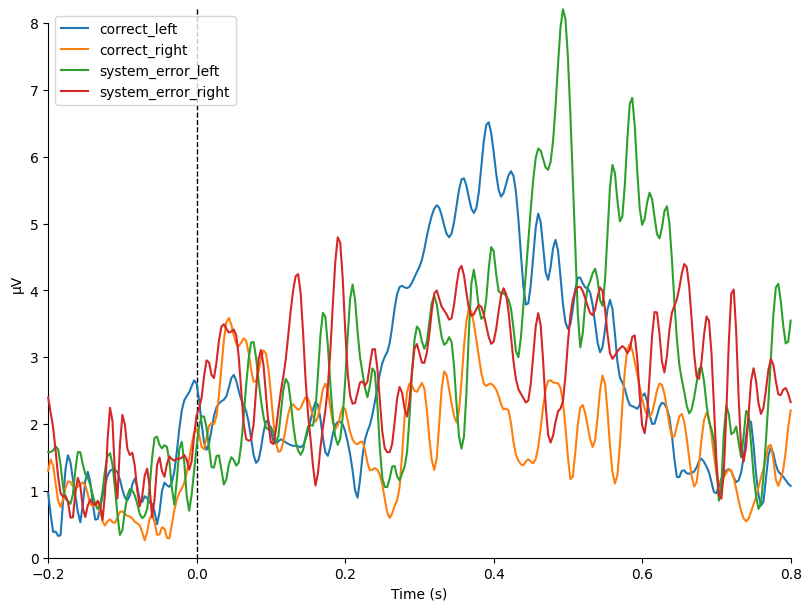

Shape of EEG data (num_trials, num_channels, epoch_len): (990, 7, 300)
Shape of labels array (num_trials,): (990,)
Shape of groups array (num_trials,): (990,)
Dataset label counts:
[['correct_left' '333']
 ['correct_right' '344']
 ['system_error_left' '150']
 ['system_error_right' '163']]
Dataset groups counts:
[[  0 249]
 [  1 245]
 [  2 247]
 [  3 249]]


In [ ]:
import numpy as np
X = []
y = []
groups = []
total_len = len(data_files)
for i, data_file in enumerate(data_files):
  print(f"Loading file #{i+1}/{total_len}")
  datum, label = load_raw_edf(data_file)
  X.append(datum)
  y.append(label)
  groups.extend([i]*datum.shape[0])
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)
groups = np.array(groups)
print(f"Shape of EEG data (num_trials, num_channels, epoch_len): {X.shape}")
print(f"Shape of labels array (num_trials,): {y.shape}")
print(f"Shape of groups array (num_trials,): {groups.shape}")
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)
unique_groups, counts = np.unique(groups,return_counts=True)
print("Dataset groups counts:")
print(np.asarray((unique_groups, counts)).T)

In [ ]:
y = [0 if 'correct' in lab else 1 for lab in y]
y = np.array(y)
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts:
[[  0 677]
 [  1 313]]


In [ ]:
!git clone https://github.com/Neurotech-BCI/ErrP.git

Cloning into 'ErrP'...
remote: Enumerating objects: 543, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 543 (delta 110), reused 87 (delta 69), pack-reused 404 (from 1)
Receiving objects: 100% (543/543), 7.19 MiB | 7.99 MiB/s, done.
Resolving deltas: 100% (305/305), done.


In [ ]:
import sys
sys.path.append("/content/ErrP")

In [ ]:
!pip install mne_features

In [ ]:
from sklearn.utils import resample
X_majority = X[y == unique_labels[0]]
y_majority = y[y == unique_labels[0]]
groups_majority = groups[y == unique_labels[0]]
X_minority = X[y == unique_labels[1]]
y_minority = y[y == unique_labels[1]]
groups_minority = groups[y == unique_labels[1]]

# Downsample majority class to match minority class size
# Set 'replace=False' for sampling without replacement (typical for downsampling)
# Set 'n_samples' to the number of samples in the minority class
X_majority_downsampled, y_majority_downsampled, groups_majority_downsampled = resample(
    X_majority, y_majority, groups_majority,
    replace=False,         # Sample without replacement
    n_samples=len(X_minority), # Match minority class size
    stratify=groups_majority,
    random_state=42        # Reproducible results
)

# Combine minority class with downsampled majority class
X = np.concatenate((X_majority_downsampled, X_minority))
y = np.concatenate((y_majority_downsampled, y_minority))
groups = np.concatenate((groups_majority_downsampled, groups_minority))
print(f"Downsampled shape: {X.shape}, {y.shape}, {groups.shape}")
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)
unique_groups, counts = np.unique(groups, return_counts=True)
print("Dataset group counts:")
print(np.asarray((unique_groups, counts)).T)

Downsampled shape: (626, 7, 300), (626,), (626,)
Dataset label counts:
[[  0 313]
 [  1 313]]
Dataset group counts:
[[  0 162]
 [  1 155]
 [  2 157]
 [  3 152]]


In [ ]:
!pip install EntropyHub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires d

In [ ]:
!pip install bayesian-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.3 MB/s eta 0:00:00


In [ ]:
from classify import FeatureWrapper
wrapper = FeatureWrapper()
desired_features=[
        'median_frequency',
        'power_bandwidth',
        'alpha_bandpower',
        "beta_bandpower",
        "theta_bandpower",
        "delta_bandpower",
        'fft_max_value',
        'rms',
        'std',
        'time_max_peak',
        'time_min_peak',
        'max_peak_value',
        'min_peak_value',
        'prominence',
        'mean_frequency',
        'snr1',
        'snr',
        'sinad',
        'peak_location',
        'wavelet_energy_2_4',
        'wavelet_energy_4_8',
]
print(f"Shape of EEG data before computing features (number_of_samples, number_of_channels, number_of_timesteps):\n{X.shape}")
print()
features = np.stack([wrapper.compute_features(sample, 300.0, desired_features=desired_features) for sample in X])
print(f"Shape of EEG data after computing features (number_of_samples, number_of_channels, number_of_features):\n{features.shape}")


Shape of EEG data before computing features (number_of_samples, number_of_channels, number_of_timesteps):
(626, 7, 300)

Shape of EEG data after computing features (number_of_samples, number_of_channels, number_of_features):
(626, 7, 21)


In [ ]:
from classify.classify import classify_sklearn
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, LeaveOneOut
accs = []
for g, data_file in zip(unique_groups, data_files):
  classifier = SVC()
  cv_splitter = LeaveOneOut()
  #cv_splitter = LeaveOneGroupOut()
  metrics = classify_sklearn(features[groups==g], y[groups==g], classifier, cv_splitter=cv_splitter, return_preds=True, use_smote=False)
  accs.append(metrics['mean_accuracy'])
  print(f"Metrics for file: {data_file}")
  print(metrics)
  print()
print(f"Average accuracy: {np.mean(accs)}")

Metrics for file: /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/RacingGame/260323_racingGame_winston_raw.edf
{'mean_accuracy': np.float64(0.654320987654321), 'mean_precision': np.float64(0.654320987654321), 'mean_recall': np.float64(0.654320987654321), 'mean_f1': np.float64(0.654320987654321), 'predictions': [(np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0),

In [ ]:
from classify.classify import classify_sklearn
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, LeaveOneOut
classifier = SVC()
cv_splitter = LeaveOneGroupOut()
metrics = classify_sklearn(features, y, classifier, cv_splitter=cv_splitter, groups=groups, return_preds=True, use_smote=False)
print(metrics)


{'mean_accuracy': np.float64(0.5272589051018295), 'mean_precision': np.float64(0.5773774754143179), 'mean_recall': np.float64(0.5272589051018295), 'mean_f1': np.float64(0.4641381194730522), 'predictions': [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(

In [ ]:
from collections import defaultdict
correct = defaultdict(int)
total = defaultdict(int)

for pred, real in metrics["predictions"]:
    total[real] += 1
    if pred == real:
        correct[real] += 1
accuracy_per_class = {cls: correct[cls] / total[cls] for cls in total}
for k, v in accuracy_per_class.items():
    print(f"Accuracy for Class {k}: {(v*100):.1f}%")
print(f"Balanced Accuracy: {(np.mean(list(accuracy_per_class.values()))*100):.1f}%")


Accuracy for Class 0: 85.0%
Accuracy for Class 1: 20.4%
Balanced Accuracy: 52.7%


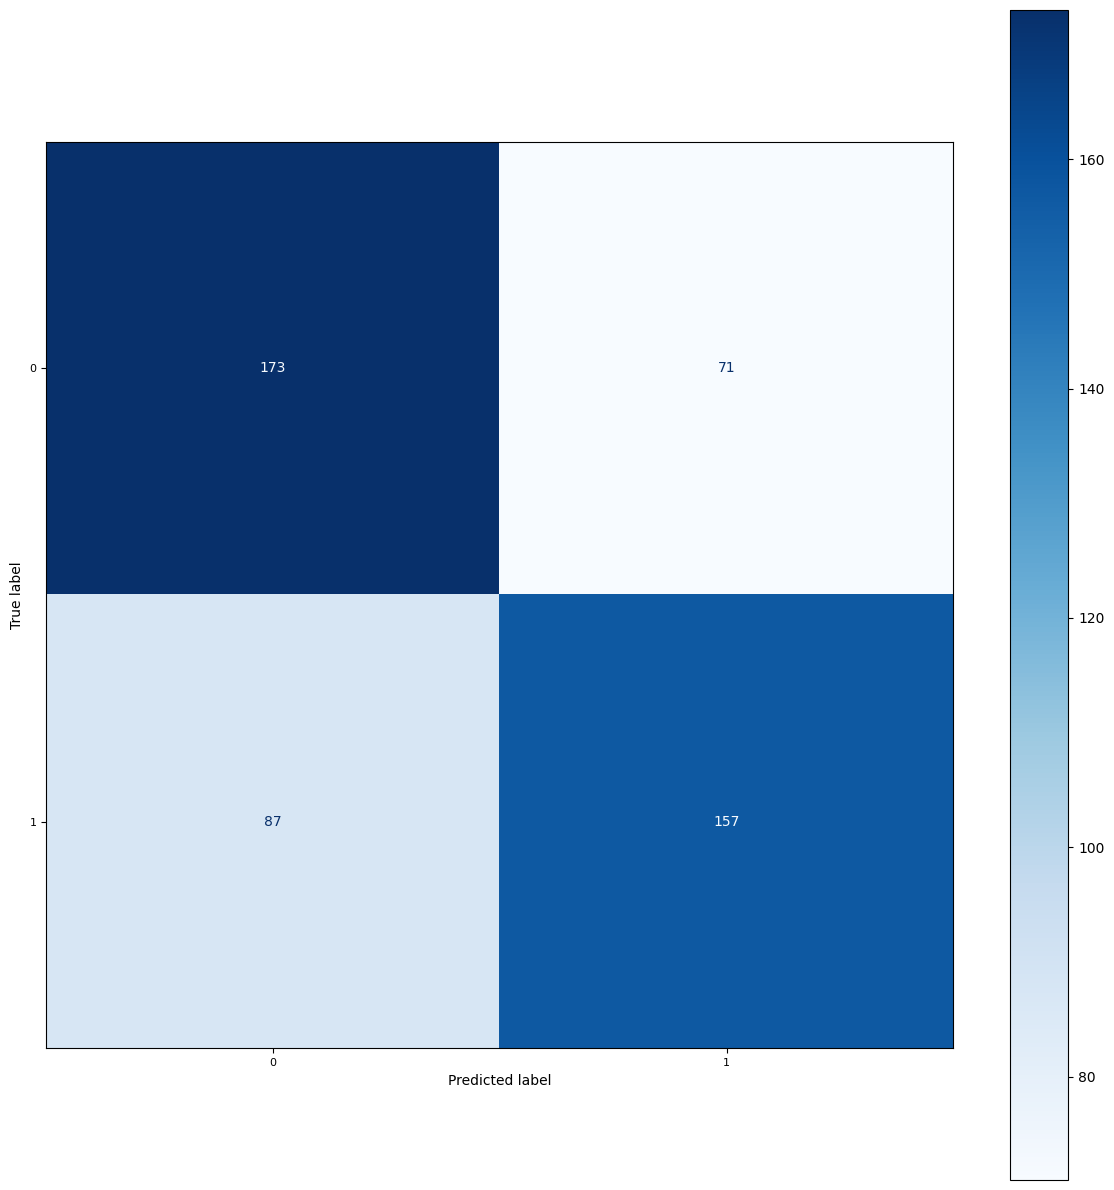

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = [p for p, _ in metrics["predictions"]]
real = [p for _, p in metrics["predictions"]]

class_names = np.unique(real)
cm = confusion_matrix(real, preds, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.xticks(rotation=0, ha="center", fontsize=8)
plt.yticks(rotation=0, ha="right", fontsize=8)

plt.tight_layout()
plt.show()